# Filtered Surface RMSE Comparison

This notebook compares the contemporaneous option-surface fit of the Normal SABR and memory-augmented Rough-SABR particle filters.

The comparison is based on paired runs that use the same random seeds,
timestamps, retained quotes, and evaluation settings. It considers:

- filtered price RMSE for each seed;
- mean RMSE and across-seed variability over time;
- paired Rough-SABR-minus-Normal-SABR RMSE differences;
- the frequency with which each model achieves the lower RMSE;
- mean absolute error; and
- bid--ask coverage.

Unlike predictive log-likelihood, this is **not an out-of-sample forecasting measure**. The RMSE is evaluated after the current option panel has been incorporated into the filter and therefore measures reconstruction of the contemporaneous surface.

## Filtered RMSE measure

For model \(M\), timestamp \(t\), and random seed \(s\), the filtered price RMSE is

$$
\operatorname{RMSE}^{M}_{t,s}
=
\sqrt{
\frac{1}{n_{t,s}}
\sum_{j=1}^{n_{t,s}}
\left(
\widehat{P}^{M}_{t,s,j}
-
P^{\mathrm{market}}_{t,s,j}
\right)^2
}.
$$

The paired difference is defined as

$$
\Delta^{\mathrm{RMSE}}_{t,s}
=
\operatorname{RMSE}^{\mathrm{Rough}}_{t,s}
-
\operatorname{RMSE}^{\mathrm{Normal}}_{t,s}.
$$

Therefore:

- \(\Delta^{\mathrm{RMSE}}_{t,s}<0\) favours Rough-SABR;
- \(\Delta^{\mathrm{RMSE}}_{t,s}>0\) favours Normal SABR.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

## Configuration

This notebook assumes that it is stored in `notebooks/` and that model outputs are stored in `outputs/`.

The folder patterns correspond to:

- Normal SABR with no additional log-\(A\) random walk;
- Rough-SABR with log-\(U\) process noise equal to zero.

In [2]:
REPOSITORY_ROOT = Path("..").resolve()
OUTPUTS_DIR = REPOSITORY_ROOT / "outputs"

NORMAL_RUN_PATTERN = "normal_sabr_400ts_no_A_RW_seed*"
ROUGH_RUN_PATTERN = "rough_sabr_400ts_logU0_seed*"

EXPECTED_SEEDS = [123, 456, 789, 101112, 131415]
MAX_TIMESTAMPS = 400

RESULTS_DIR = (
    OUTPUTS_DIR
    / "comparisons"
    / "filtered_rmse"
)
FIGURE_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs directory:", OUTPUTS_DIR)
print("Results directory:", RESULTS_DIR)

Outputs directory: C:\Users\maria\Project\Thesis_project\Memory-Augmented-Rough-SABR-MARS-Filter\outputs
Results directory: C:\Users\maria\Project\Thesis_project\Memory-Augmented-Rough-SABR-MARS-Filter\outputs\comparisons\filtered_rmse


## Load and align paired runs

In [3]:
def extract_seed(folder: Path) -> int:
    match = re.search(r"seed(\d+)", folder.name)

    if match is None:
        raise ValueError(f"Seed not found in folder name: {folder.name}")

    return int(match.group(1))


def load_rmse(csv_path: Path, column_name: str) -> pd.DataFrame:
    data = pd.read_csv(csv_path)

    required_columns = {"t_index", "fit_price_rmse"}
    missing = required_columns.difference(data.columns)

    if missing:
        raise ValueError(
            f"{csv_path} is missing required columns: {sorted(missing)}"
        )

    columns = ["t_index", "fit_price_rmse"]

    for optional_column in ["capture_time_utc", "n_quotes"]:
        if optional_column in data.columns:
            columns.append(optional_column)

    result = data[columns].copy()
    result["t_index"] = pd.to_numeric(result["t_index"], errors="coerce")
    result["fit_price_rmse"] = pd.to_numeric(
        result["fit_price_rmse"],
        errors="coerce",
    )

    result = (
        result
        .dropna(subset=["t_index", "fit_price_rmse"])
        .sort_values("t_index")
        .drop_duplicates("t_index")
        .reset_index(drop=True)
    )

    result["t_index"] = result["t_index"].astype(int)

    return result.rename(columns={"fit_price_rmse": column_name})

In [4]:
normal_runs = {
    extract_seed(folder): folder
    for folder in OUTPUTS_DIR.glob(NORMAL_RUN_PATTERN)
    if folder.is_dir()
}

rough_runs = {
    extract_seed(folder): folder
    for folder in OUTPUTS_DIR.glob(ROUGH_RUN_PATTERN)
    if folder.is_dir()
}

available_seeds = sorted(set(normal_runs) & set(rough_runs))
seeds = [seed for seed in EXPECTED_SEEDS if seed in available_seeds]

missing_seeds = sorted(set(EXPECTED_SEEDS).difference(seeds))

if missing_seeds:
    raise ValueError(
        "Paired runs are missing for seeds: "
        f"{missing_seeds}"
    )

print("Paired seeds:", seeds)

Paired seeds: [123, 456, 789, 101112, 131415]


In [5]:
paired_runs = []

for seed in seeds:
    normal = load_rmse(
        normal_runs[seed] / "surface_rmse_over_time.csv",
        "normal_rmse",
    )

    rough = load_rmse(
        rough_runs[seed] / "surface_rmse_over_time.csv",
        "rough_rmse",
    )

    merge_columns = ["t_index"]

    if (
        "capture_time_utc" in normal.columns
        and "capture_time_utc" in rough.columns
    ):
        merge_columns.append("capture_time_utc")

    paired_seed = normal.merge(
        rough,
        on=merge_columns,
        how="inner",
        validate="one_to_one",
        suffixes=("_normal", "_rough"),
    )

    if (
        "n_quotes_normal" in paired_seed.columns
        and "n_quotes_rough" in paired_seed.columns
    ):
        unequal_quotes = (
            paired_seed["n_quotes_normal"]
            != paired_seed["n_quotes_rough"]
        )

        if unequal_quotes.any():
            affected = paired_seed.loc[
                unequal_quotes,
                "t_index",
            ].tolist()

            raise ValueError(
                f"Quote counts differ for seed {seed}. "
                f"First affected timestamps: {affected[:10]}"
            )

    paired_seed["seed"] = seed
    paired_runs.append(paired_seed)

common_timestamps = sorted(
    set.intersection(
        *[
            set(frame["t_index"])
            for frame in paired_runs
        ]
    )
)

if MAX_TIMESTAMPS is not None:
    common_timestamps = common_timestamps[:MAX_TIMESTAMPS]

rmse = pd.concat(paired_runs, ignore_index=True)

rmse = (
    rmse[rmse["t_index"].isin(common_timestamps)]
    .sort_values(["seed", "t_index"])
    .reset_index(drop=True)
)

observations_per_seed = rmse.groupby("seed")["t_index"].nunique()

if observations_per_seed.nunique() != 1:
    raise ValueError(
        "The paired runs do not contain the same timestamps."
    )

print(
    f"Comparison uses {len(seeds)} seeds and "
    f"{observations_per_seed.iloc[0]} timestamps per seed."
)

Comparison uses 5 seeds and 400 timestamps per seed.


## Construct comparison measures

In [6]:
rmse["rough_minus_normal_rmse"] = (
    rmse["rough_rmse"]
    - rmse["normal_rmse"]
)

rmse["rough_has_lower_rmse"] = (
    rmse["rough_minus_normal_rmse"] < 0
)

rmse.to_csv(
    RESULTS_DIR / "paired_filtered_rmse_all_seeds.csv",
    index=False,
)

rmse.head()

,t_index,normal_rmse,capture_time_utc,n_quotes_normal,rough_rmse,n_quotes_rough,seed,rough_minus_normal_rmse,rough_has_lower_rmse
0,0,0.001489,2026-05-26T13:25:12+0000,77,0.001361,77,123,-0.000129,True
1,1,0.001645,2026-05-26T13:30:12+0000,77,0.001942,77,123,0.000297,False
2,2,0.003190,2026-05-26T13:33:28+0000,77,0.001088,77,123,-0.002102,True
3,3,0.002710,2026-05-26T13:38:28+0000,77,0.001783,77,123,-0.000927,True
4,4,0.002908,2026-05-26T13:43:28+0000,77,0.002684,77,123,-0.000225,True


## Seed-level and overall summary

In [7]:
seed_summary = (
    rmse.groupby("seed", as_index=False)
    .agg(
        timestamps=("t_index", "nunique"),
        normal_mean_rmse=("normal_rmse", "mean"),
        rough_mean_rmse=("rough_rmse", "mean"),
        normal_median_rmse=("normal_rmse", "median"),
        rough_median_rmse=("rough_rmse", "median"),
        mean_paired_difference=(
            "rough_minus_normal_rmse",
            "mean",
        ),
        median_paired_difference=(
            "rough_minus_normal_rmse",
            "median",
        ),
        rough_win_percentage=(
            "rough_has_lower_rmse",
            lambda x: 100 * x.mean(),
        ),
    )
)

seed_summary["preferred_model"] = np.where(
    seed_summary["rough_mean_rmse"]
    < seed_summary["normal_mean_rmse"],
    "Rough-SABR",
    "Normal SABR",
)

display(
    seed_summary.style.format(
        {
            "normal_mean_rmse": "{:.6f}",
            "rough_mean_rmse": "{:.6f}",
            "normal_median_rmse": "{:.6f}",
            "rough_median_rmse": "{:.6f}",
            "mean_paired_difference": "{:.6f}",
            "median_paired_difference": "{:.6f}",
            "rough_win_percentage": "{:.2f}%",
        }
    )
)

seed_summary.to_csv(
    RESULTS_DIR / "filtered_rmse_summary_by_seed.csv",
    index=False,
)

,seed,timestamps,normal_mean_rmse,rough_mean_rmse,normal_median_rmse,rough_median_rmse,mean_paired_difference,median_paired_difference,rough_win_percentage,preferred_model
0,123,400,0.001773,0.001718,0.001663,0.001634,-0.000054,-0.000064,54.75%,Rough-SABR
1,456,400,0.001880,0.001774,0.001775,0.001668,-0.000106,-0.000115,56.50%,Rough-SABR
2,789,400,0.001758,0.001792,0.001700,0.001685,0.000034,0.000039,47.75%,Normal SABR
3,101112,400,0.001773,0.001717,0.001690,0.001647,-0.000055,-0.000099,54.25%,Rough-SABR
4,131415,400,0.001979,0.001731,0.001932,0.001685,-0.000248,-0.000281,63.50%,Rough-SABR


In [8]:
normal_mean = seed_summary["normal_mean_rmse"].mean()
rough_mean = seed_summary["rough_mean_rmse"].mean()

normal_seed_sd = seed_summary["normal_mean_rmse"].std()
rough_seed_sd = seed_summary["rough_mean_rmse"].std()

relative_rmse_reduction = (
    100 * (normal_mean - rough_mean) / normal_mean
)

relative_seed_sd_reduction = (
    100 * (normal_seed_sd - rough_seed_sd) / normal_seed_sd
)

overall_summary = pd.DataFrame(
    {
        "metric": [
            "Normal SABR mean of seed-level mean RMSE",
            "Rough-SABR mean of seed-level mean RMSE",
            "Relative RMSE reduction from Rough-SABR",
            "Normal SABR across-seed SD of mean RMSE",
            "Rough-SABR across-seed SD of mean RMSE",
            "Relative reduction in across-seed RMSE variability",
            "Mean paired Rough minus Normal RMSE",
            "Median paired Rough minus Normal RMSE",
            "Fraction of seed-timestamps favouring Rough",
        ],
        "value": [
            normal_mean,
            rough_mean,
            relative_rmse_reduction,
            normal_seed_sd,
            rough_seed_sd,
            relative_seed_sd_reduction,
            rmse["rough_minus_normal_rmse"].mean(),
            rmse["rough_minus_normal_rmse"].median(),
            rmse["rough_has_lower_rmse"].mean(),
        ],
    }
)

display(overall_summary)

overall_summary.to_csv(
    RESULTS_DIR / "filtered_rmse_overall_summary.csv",
    index=False,
)

,metric,value
0,Normal SABR mean of seed-level mean RMSE,0.001833
1,Rough-SABR mean of seed-level mean RMSE,0.001747
2,Relative RMSE reduction from Rough-SABR,4.692319
3,Normal SABR across-seed SD of mean RMSE,0.000096
4,Rough-SABR across-seed SD of mean RMSE,0.000034
5,Relative reduction in across-seed RMSE variabi...,63.920420
6,Mean paired Rough minus Normal RMSE,-0.000086
7,Median paired Rough minus Normal RMSE,-0.000107
8,Fraction of seed-timestamps favouring Rough,0.553500


## 1. Filtered surface RMSE by seed

Each figure compares the paired Normal SABR and Rough-SABR filtered RMSE paths for one seed.

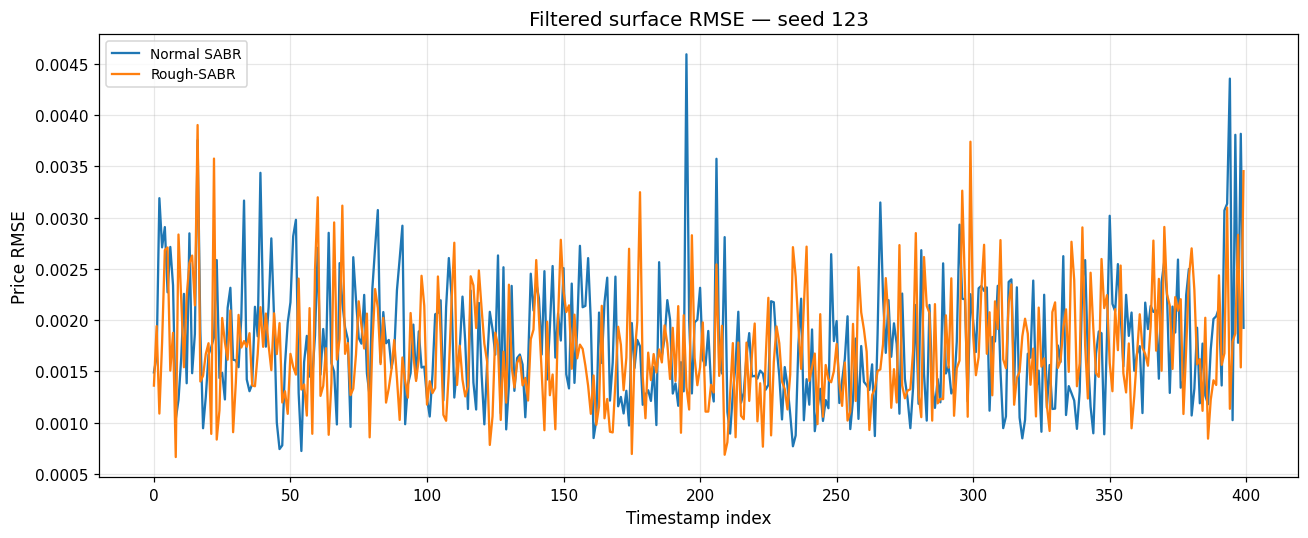

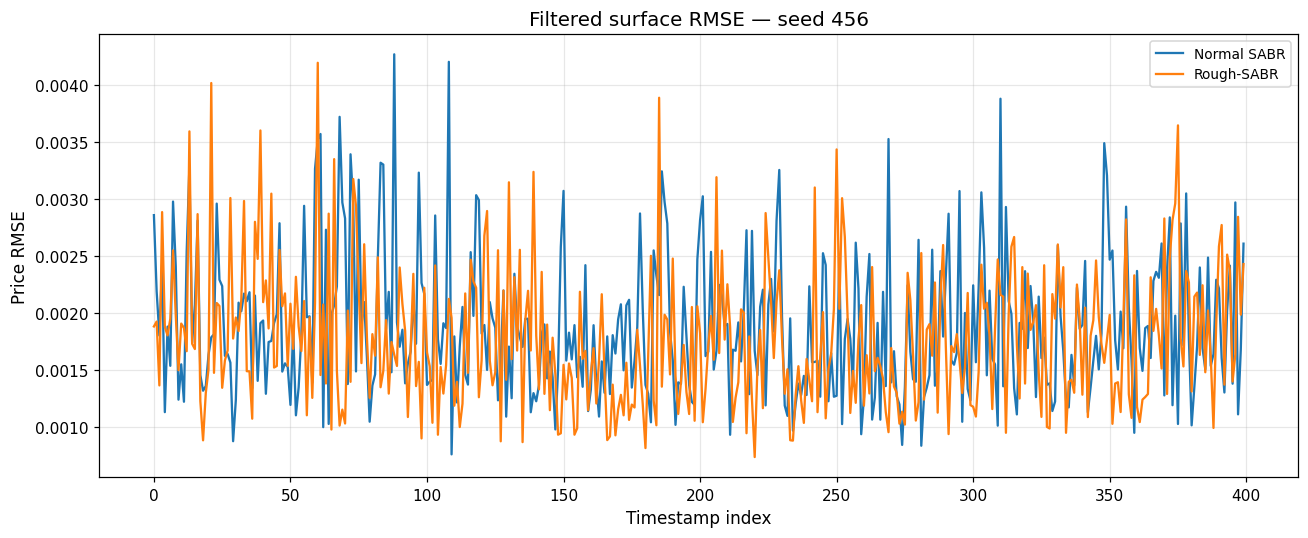

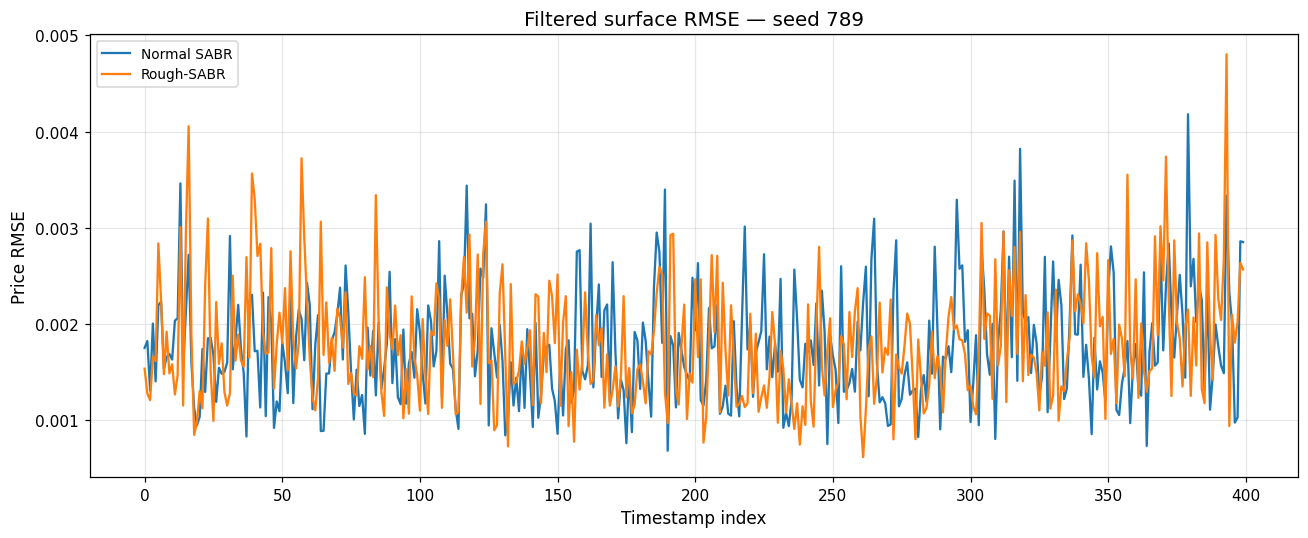

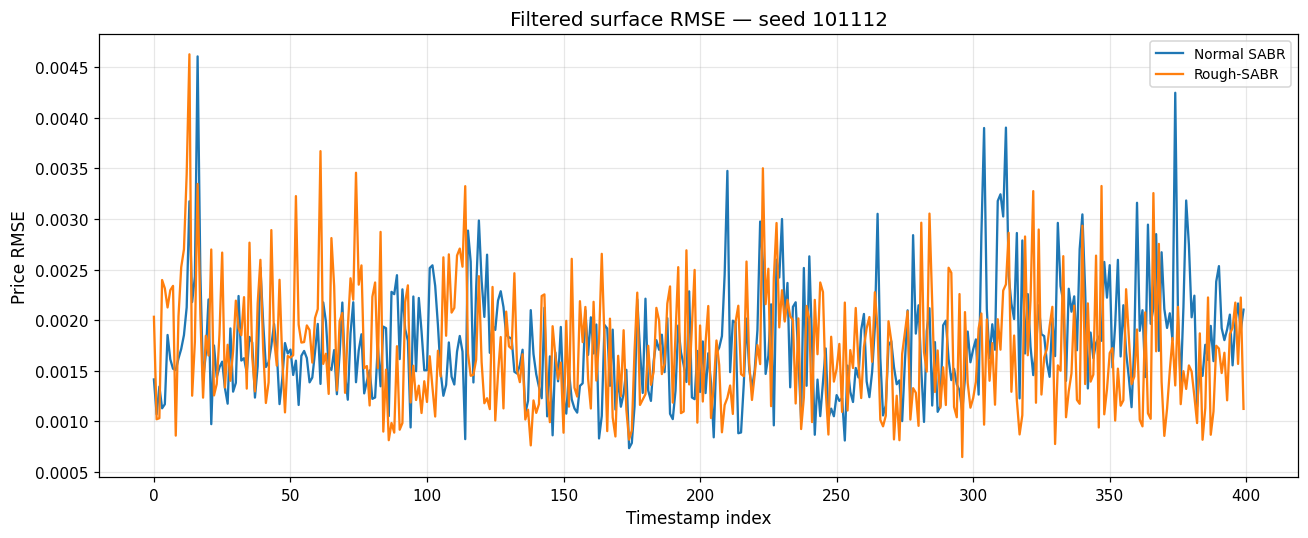

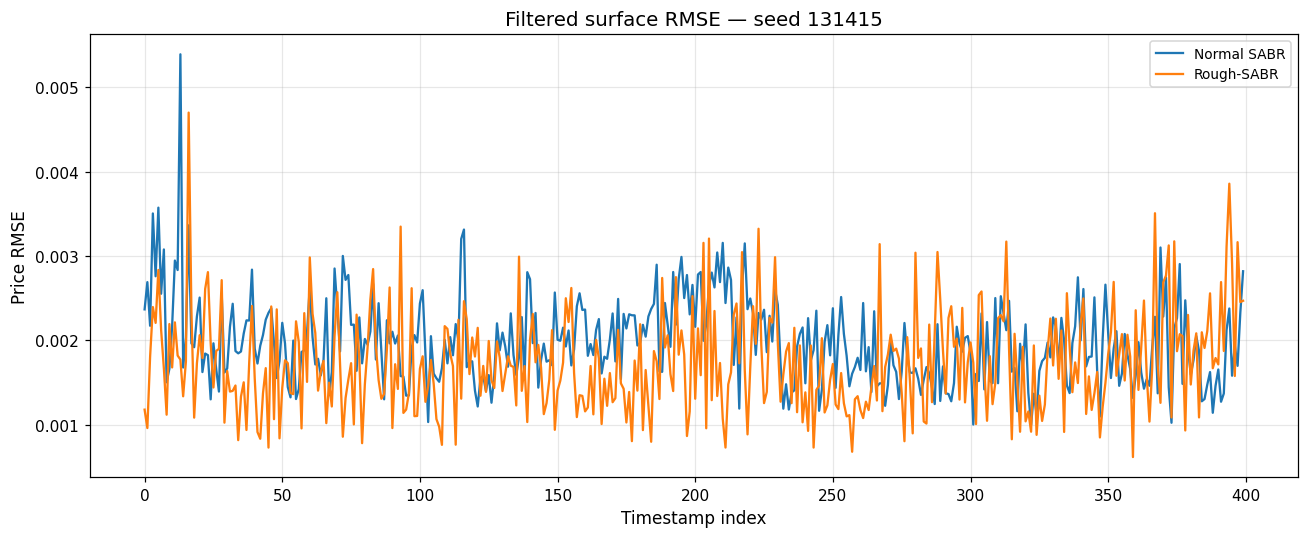

In [9]:
for seed, seed_data in rmse.groupby("seed"):
    fig, ax = plt.subplots()

    ax.plot(
        seed_data["t_index"],
        seed_data["normal_rmse"],
        linewidth=1.5,
        label="Normal SABR",
    )

    ax.plot(
        seed_data["t_index"],
        seed_data["rough_rmse"],
        linewidth=1.5,
        label="Rough-SABR",
    )

    ax.set_title(f"Filtered surface RMSE — seed {seed}")
    ax.set_xlabel("Timestamp index")
    ax.set_ylabel("Price RMSE")
    ax.grid(alpha=0.3)
    ax.legend()

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"filtered_rmse_seed_{seed}.png",
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

## 2. Filtered surface RMSE across seeds

The solid lines show the mean across seeds. The shaded regions show one standard deviation across seeds.

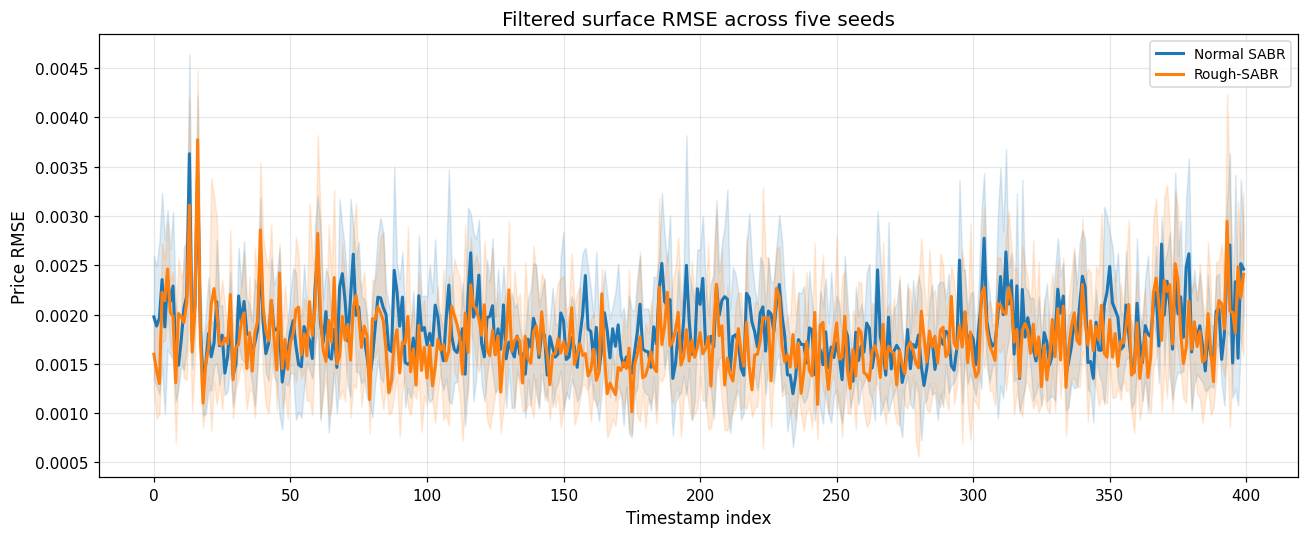

In [10]:
across_seeds = (
    rmse.groupby("t_index", as_index=False)
    .agg(
        normal_rmse_mean=("normal_rmse", "mean"),
        normal_rmse_std=("normal_rmse", "std"),
        rough_rmse_mean=("rough_rmse", "mean"),
        rough_rmse_std=("rough_rmse", "std"),
        paired_difference_mean=(
            "rough_minus_normal_rmse",
            "mean",
        ),
        paired_difference_std=(
            "rough_minus_normal_rmse",
            "std",
        ),
        fraction_of_seeds_favouring_rough=(
            "rough_has_lower_rmse",
            "mean",
        ),
    )
)

fig, ax = plt.subplots()

normal_line = ax.plot(
    across_seeds["t_index"],
    across_seeds["normal_rmse_mean"],
    linewidth=2,
    label="Normal SABR",
)[0]

ax.fill_between(
    across_seeds["t_index"],
    across_seeds["normal_rmse_mean"]
    - across_seeds["normal_rmse_std"],
    across_seeds["normal_rmse_mean"]
    + across_seeds["normal_rmse_std"],
    color=normal_line.get_color(),
    alpha=0.15,
)

rough_line = ax.plot(
    across_seeds["t_index"],
    across_seeds["rough_rmse_mean"],
    linewidth=2,
    label="Rough-SABR",
)[0]

ax.fill_between(
    across_seeds["t_index"],
    across_seeds["rough_rmse_mean"]
    - across_seeds["rough_rmse_std"],
    across_seeds["rough_rmse_mean"]
    + across_seeds["rough_rmse_std"],
    color=rough_line.get_color(),
    alpha=0.15,
)

ax.set_title("Filtered surface RMSE across five seeds")
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Price RMSE")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "filtered_rmse_across_seeds.png",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

across_seeds.to_csv(
    RESULTS_DIR / "filtered_rmse_summary_by_timestamp.csv",
    index=False,
)

## 3. Across-seed RMSE variability

The across-seed standard deviation measures the sensitivity of each model's filtered RMSE to the random seed at each timestamp. Lower values indicate greater robustness to Monte Carlo and particle-filter randomness.

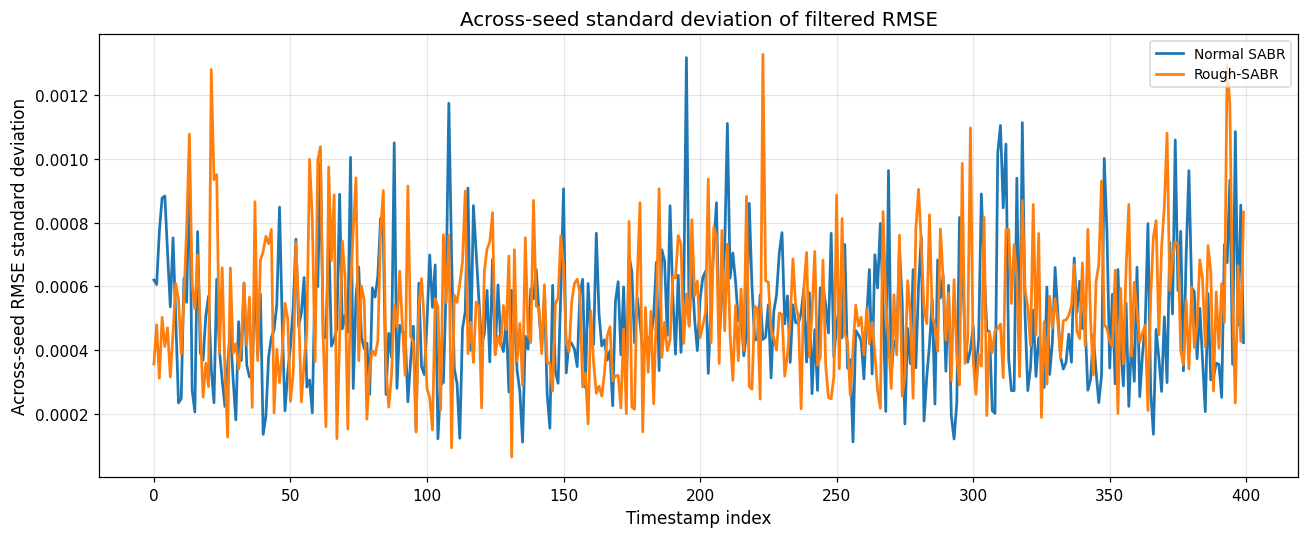

In [11]:
fig, ax = plt.subplots()

ax.plot(
    across_seeds["t_index"],
    across_seeds["normal_rmse_std"],
    linewidth=1.8,
    label="Normal SABR",
)

ax.plot(
    across_seeds["t_index"],
    across_seeds["rough_rmse_std"],
    linewidth=1.8,
    label="Rough-SABR",
)

ax.set_title("Across-seed standard deviation of filtered RMSE")
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Across-seed RMSE standard deviation")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "filtered_rmse_across_seed_std.png",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

## 4. Win rates and distribution of paired RMSE differences

The win rate shows how often Rough-SABR has the lower filtered RMSE. The distribution clarifies whether the average result is broad-based or driven by a small number of extreme timestamps.

,seed,observations,rough_win_percentage,mean_difference,median_difference,standard_deviation,minimum_difference,percentile_5,percentile_95,maximum_difference
0,123,400,54.75%,-0.000054,-0.000064,0.000777,-0.003247,-0.001300,0.001179,0.001943
1,456,400,56.50%,-0.000106,-0.000115,0.000838,-0.002707,-0.001530,0.001395,0.002618
2,789,400,47.75%,0.000034,0.000039,0.000738,-0.002105,-0.001193,0.001260,0.002177
3,101112,400,54.25%,-0.000055,-0.000099,0.000797,-0.002932,-0.001291,0.001279,0.002501
4,131415,400,63.50%,-0.000248,-0.000281,0.000745,-0.003618,-0.001412,0.001000,0.001772
5,Overall,2000,55.35%,-0.000086,-0.000107,0.000785,-0.003618,-0.001365,0.001246,0.002618


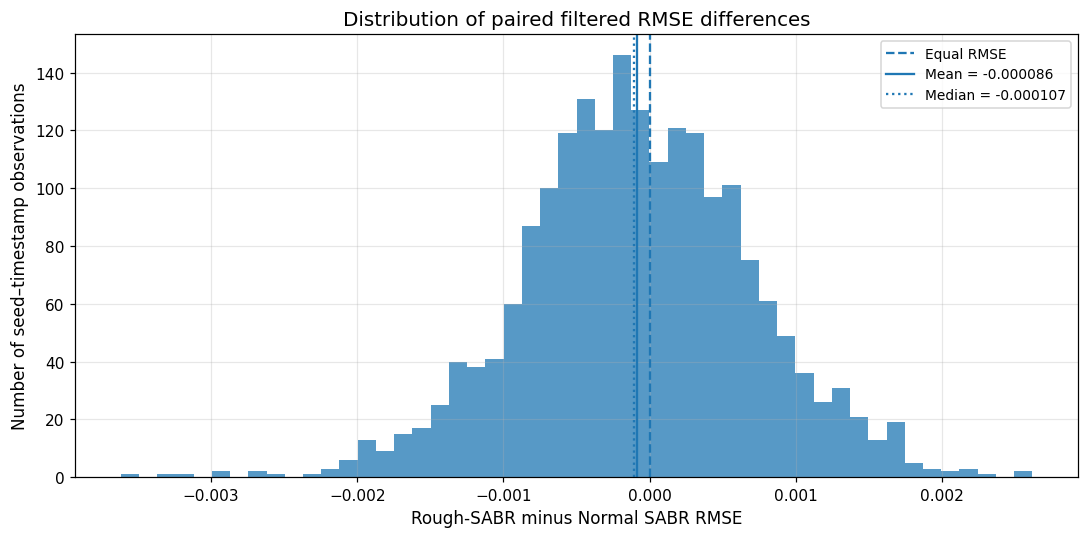

In [14]:
distribution_by_seed = (
    rmse.groupby("seed", as_index=False)
    .agg(
        observations=("rough_minus_normal_rmse", "count"),
        rough_win_percentage=(
            "rough_has_lower_rmse",
            lambda x: 100 * x.mean(),
        ),
        mean_difference=(
            "rough_minus_normal_rmse",
            "mean",
        ),
        median_difference=(
            "rough_minus_normal_rmse",
            "median",
        ),
        standard_deviation=(
            "rough_minus_normal_rmse",
            "std",
        ),
        minimum_difference=(
            "rough_minus_normal_rmse",
            "min",
        ),
        percentile_5=(
            "rough_minus_normal_rmse",
            lambda x: x.quantile(0.05),
        ),
        percentile_95=(
            "rough_minus_normal_rmse",
            lambda x: x.quantile(0.95),
        ),
        maximum_difference=(
            "rough_minus_normal_rmse",
            "max",
        ),
    )
)

difference = rmse["rough_minus_normal_rmse"].dropna()

overall_distribution = pd.DataFrame(
    {
        "seed": ["Overall"],
        "observations": [difference.count()],
        "rough_win_percentage": [
            100 * (difference < 0).mean()
        ],
        "mean_difference": [difference.mean()],
        "median_difference": [difference.median()],
        "standard_deviation": [difference.std()],
        "minimum_difference": [difference.min()],
        "percentile_5": [difference.quantile(0.05)],
        "percentile_95": [difference.quantile(0.95)],
        "maximum_difference": [difference.max()],
    }
)

rmse_difference_distribution = pd.concat(
    [distribution_by_seed, overall_distribution],
    ignore_index=True,
)

display(
    rmse_difference_distribution.style.format(
        {
            "rough_win_percentage": "{:.2f}%",
            "mean_difference": "{:.6f}",
            "median_difference": "{:.6f}",
            "standard_deviation": "{:.6f}",
            "minimum_difference": "{:.6f}",
            "percentile_5": "{:.6f}",
            "percentile_95": "{:.6f}",
            "maximum_difference": "{:.6f}",
        }
    )
)

rmse_difference_distribution.to_csv(
    RESULTS_DIR / "filtered_rmse_difference_distribution.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    difference,
    bins=50,
    alpha=0.75,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Equal RMSE",
)

ax.axvline(
    difference.mean(),
    linewidth=1.5,
    label=f"Mean = {difference.mean():.6f}",
)

ax.axvline(
    difference.median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {difference.median():.6f}",
)

ax.set_title("Distribution of paired filtered RMSE differences")
ax.set_xlabel("Rough-SABR minus Normal SABR RMSE")
ax.set_ylabel("Number of seed–timestamp observations")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "filtered_rmse_difference_distribution.png",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

## 5. Mean absolute error and bid–ask coverage

RMSE gives additional weight to large errors. Mean absolute error provides a more robust measure of typical pricing error, while the bid–ask coverage rate measures the proportion of filtered prices that lie inside the observed market interval.

For MAE, a negative Rough-SABR-minus-Normal-SABR difference favours Rough-SABR. For bid–ask coverage, a positive difference favours Rough-SABR.

In [16]:
def load_additional_fit_metrics(
    csv_path: Path,
    model_prefix: str,
) -> pd.DataFrame:
    data = pd.read_csv(csv_path)

    required = {
        "t_index",
        "fit_mean_abs_price_residual",
        "fit_inside_bidask_rate",
    }
    missing = required.difference(data.columns)

    if missing:
        raise ValueError(
            f"{csv_path} is missing required columns: "
            f"{sorted(missing)}"
        )

    columns = [
        "t_index",
        "fit_mean_abs_price_residual",
        "fit_inside_bidask_rate",
    ]

    for optional_column in ["capture_time_utc", "n_quotes"]:
        if optional_column in data.columns:
            columns.append(optional_column)

    result = data[columns].copy()

    numeric_columns = [
        "t_index",
        "fit_mean_abs_price_residual",
        "fit_inside_bidask_rate",
    ]

    for column in numeric_columns:
        result[column] = pd.to_numeric(
            result[column],
            errors="coerce",
        )

    result = (
        result
        .dropna(
            subset=[
                "t_index",
                "fit_mean_abs_price_residual",
                "fit_inside_bidask_rate",
            ]
        )
        .sort_values("t_index")
        .drop_duplicates("t_index")
        .reset_index(drop=True)
    )

    result["t_index"] = result["t_index"].astype(int)

    return result.rename(
        columns={
            "fit_mean_abs_price_residual": (
                f"{model_prefix}_mae"
            ),
            "fit_inside_bidask_rate": (
                f"{model_prefix}_inside_bidask_rate"
            ),
            "n_quotes": f"{model_prefix}_n_quotes",
        }
    )

In [17]:
additional_metric_pairs = []

for seed in seeds:
    normal_metrics = load_additional_fit_metrics(
        normal_runs[seed] / "surface_rmse_over_time.csv",
        "normal",
    )

    rough_metrics = load_additional_fit_metrics(
        rough_runs[seed] / "surface_rmse_over_time.csv",
        "rough",
    )

    merge_columns = ["t_index"]

    if (
        "capture_time_utc" in normal_metrics.columns
        and "capture_time_utc" in rough_metrics.columns
    ):
        merge_columns.append("capture_time_utc")

    paired_metrics = normal_metrics.merge(
        rough_metrics,
        on=merge_columns,
        how="inner",
        validate="one_to_one",
    )

    if (
        "normal_n_quotes" in paired_metrics.columns
        and "rough_n_quotes" in paired_metrics.columns
    ):
        unequal_quotes = (
            paired_metrics["normal_n_quotes"]
            != paired_metrics["rough_n_quotes"]
        )

        if unequal_quotes.any():
            raise ValueError(
                f"Normal and Rough quote counts differ "
                f"for seed {seed}."
            )

    paired_metrics["seed"] = seed
    paired_metrics["rough_minus_normal_mae"] = (
        paired_metrics["rough_mae"]
        - paired_metrics["normal_mae"]
    )
    paired_metrics["rough_minus_normal_inside_rate"] = (
        paired_metrics["rough_inside_bidask_rate"]
        - paired_metrics["normal_inside_bidask_rate"]
    )
    paired_metrics["rough_has_lower_mae"] = (
        paired_metrics["rough_minus_normal_mae"] < 0
    )
    paired_metrics["rough_has_higher_inside_rate"] = (
        paired_metrics[
            "rough_minus_normal_inside_rate"
        ] > 0
    )

    additional_metric_pairs.append(paired_metrics)

fit_metrics = pd.concat(
    additional_metric_pairs,
    ignore_index=True,
)

fit_metrics = (
    fit_metrics[
        fit_metrics["t_index"].isin(common_timestamps)
    ]
    .sort_values(["seed", "t_index"])
    .reset_index(drop=True)
)

fit_metrics.to_csv(
    RESULTS_DIR / "paired_mae_and_bidask_coverage.csv",
    index=False,
)

In [18]:
fit_metric_summary_by_seed = (
    fit_metrics.groupby("seed", as_index=False)
    .agg(
        normal_mean_mae=("normal_mae", "mean"),
        rough_mean_mae=("rough_mae", "mean"),
        mean_mae_difference=(
            "rough_minus_normal_mae",
            "mean",
        ),
        rough_lower_mae_percentage=(
            "rough_has_lower_mae",
            lambda x: 100 * x.mean(),
        ),
        normal_mean_inside_rate=(
            "normal_inside_bidask_rate",
            "mean",
        ),
        rough_mean_inside_rate=(
            "rough_inside_bidask_rate",
            "mean",
        ),
        mean_inside_rate_difference=(
            "rough_minus_normal_inside_rate",
            "mean",
        ),
        rough_higher_inside_rate_percentage=(
            "rough_has_higher_inside_rate",
            lambda x: 100 * x.mean(),
        ),
    )
)

overall_fit_metrics = pd.DataFrame(
    {
        "seed": ["Overall"],
        "normal_mean_mae": [
            fit_metric_summary_by_seed[
                "normal_mean_mae"
            ].mean()
        ],
        "rough_mean_mae": [
            fit_metric_summary_by_seed[
                "rough_mean_mae"
            ].mean()
        ],
        "mean_mae_difference": [
            fit_metrics[
                "rough_minus_normal_mae"
            ].mean()
        ],
        "rough_lower_mae_percentage": [
            100 * fit_metrics["rough_has_lower_mae"].mean()
        ],
        "normal_mean_inside_rate": [
            fit_metric_summary_by_seed[
                "normal_mean_inside_rate"
            ].mean()
        ],
        "rough_mean_inside_rate": [
            fit_metric_summary_by_seed[
                "rough_mean_inside_rate"
            ].mean()
        ],
        "mean_inside_rate_difference": [
            fit_metrics[
                "rough_minus_normal_inside_rate"
            ].mean()
        ],
        "rough_higher_inside_rate_percentage": [
            100
            * fit_metrics[
                "rough_has_higher_inside_rate"
            ].mean()
        ],
    }
)

fit_metric_summary = pd.concat(
    [
        fit_metric_summary_by_seed,
        overall_fit_metrics,
    ],
    ignore_index=True,
)

display(
    fit_metric_summary.style.format(
        {
            "normal_mean_mae": "{:.6f}",
            "rough_mean_mae": "{:.6f}",
            "mean_mae_difference": "{:.6f}",
            "rough_lower_mae_percentage": "{:.2f}%",
            "normal_mean_inside_rate": "{:.2%}",
            "rough_mean_inside_rate": "{:.2%}",
            "mean_inside_rate_difference": "{:.2%}",
            "rough_higher_inside_rate_percentage": "{:.2f}%",
        }
    )
)

fit_metric_summary.to_csv(
    RESULTS_DIR / "mae_and_bidask_summary.csv",
    index=False,
)

,seed,normal_mean_mae,rough_mean_mae,mean_mae_difference,rough_lower_mae_percentage,normal_mean_inside_rate,rough_mean_inside_rate,mean_inside_rate_difference,rough_higher_inside_rate_percentage
0,123,0.001112,0.001082,-0.000030,53.50%,52.22%,52.56%,0.34%,49.75%
1,456,0.001183,0.001114,-0.000069,57.00%,51.10%,51.98%,0.88%,48.50%
2,789,0.001114,0.001114,0.000000,48.50%,51.60%,52.19%,0.59%,47.75%
3,101112,0.001138,0.001081,-0.000057,58.00%,51.21%,52.78%,1.57%,53.00%
4,131415,0.001355,0.001092,-0.000263,70.50%,45.98%,52.20%,6.22%,72.50%
5,Overall,0.001180,0.001096,-0.000084,57.50%,50.42%,52.34%,1.92%,54.30%


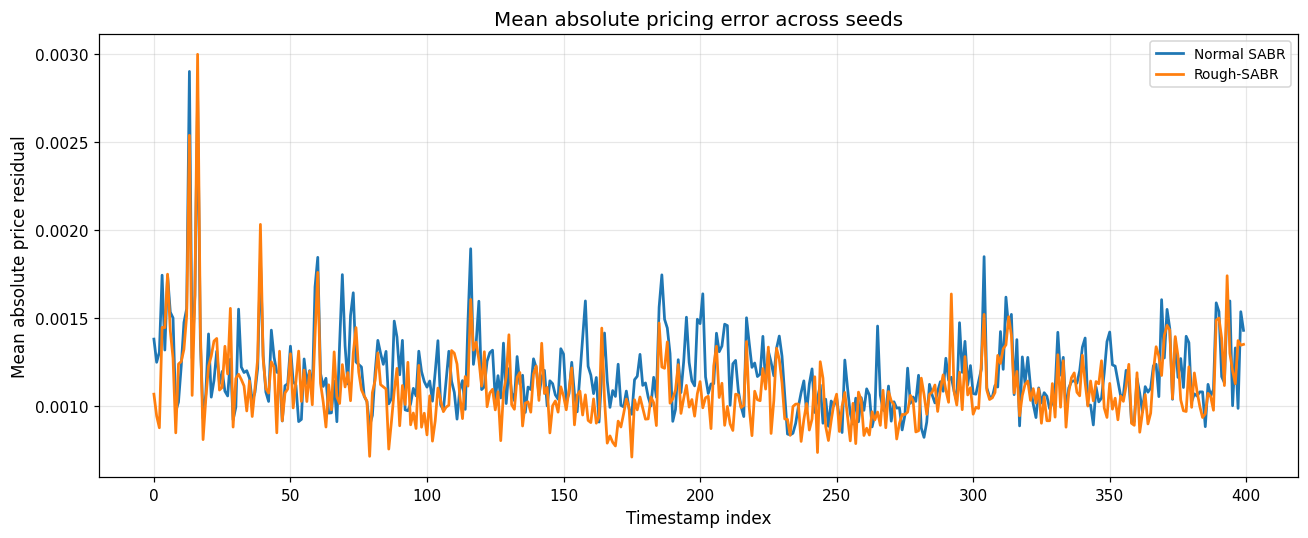

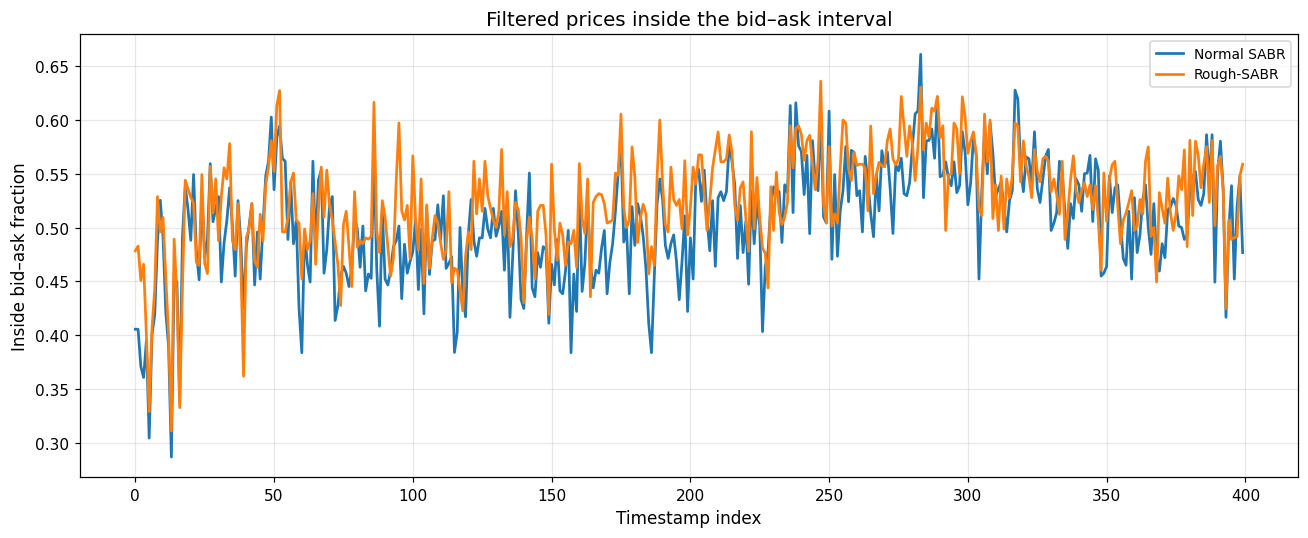

In [19]:
fit_metrics_across_seeds = (
    fit_metrics.groupby("t_index", as_index=False)
    .agg(
        normal_mae_mean=("normal_mae", "mean"),
        rough_mae_mean=("rough_mae", "mean"),
        normal_inside_rate_mean=(
            "normal_inside_bidask_rate",
            "mean",
        ),
        rough_inside_rate_mean=(
            "rough_inside_bidask_rate",
            "mean",
        ),
    )
)

fig, ax = plt.subplots()

ax.plot(
    fit_metrics_across_seeds["t_index"],
    fit_metrics_across_seeds["normal_mae_mean"],
    linewidth=1.8,
    label="Normal SABR",
)

ax.plot(
    fit_metrics_across_seeds["t_index"],
    fit_metrics_across_seeds["rough_mae_mean"],
    linewidth=1.8,
    label="Rough-SABR",
)

ax.set_title("Mean absolute pricing error across seeds")
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Mean absolute price residual")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "filtered_mae_across_seeds.png",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)


fig, ax = plt.subplots()

ax.plot(
    fit_metrics_across_seeds["t_index"],
    fit_metrics_across_seeds[
        "normal_inside_rate_mean"
    ],
    linewidth=1.8,
    label="Normal SABR",
)

ax.plot(
    fit_metrics_across_seeds["t_index"],
    fit_metrics_across_seeds[
        "rough_inside_rate_mean"
    ],
    linewidth=1.8,
    label="Rough-SABR",
)

ax.set_title("Filtered prices inside the bid–ask interval")
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Inside bid–ask fraction")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "filtered_bidask_coverage_across_seeds.png",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)